# 1.1 Correctness

1.1 Correctness: run all four conv2d implementations on the standard test
case (128x128 crop of base_2048.png, k=7 Gaussian), verify against
scipy.signal.convolve2d, and display the per-method |error| heatmap.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d  # checking only

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import kernel_bank, conv2d_loops, conv2d_taps, conv2d_im2col, conv2d_fft

ROOT = Path.cwd().parents[1]

In [4]:
img = np.asarray(Image.open(ROOT / "Images/input/P1/base_2048.png")).astype(float)[:128, :128]
K = kernel_bank(7)["gaussian"]
ref = convolve2d(img, K, mode="same", boundary="fill")

In [5]:
methods = {
    "conv2d_loops": conv2d_loops,
    "conv2d_taps": conv2d_taps,
    "conv2d_im2col": conv2d_im2col,
    "conv2d_fft": conv2d_fft,
}

In [6]:
outputs = {}
errors = {}
for name, fn in methods.items():
    out = fn(img, K)
    outputs[name] = out
    err = np.abs(out - ref)
    errors[name] = err
    print(f"{name:16s} max|err| = {err.max():.3e}")

conv2d_loops     max|err| = 1.990e-13
conv2d_taps      max|err| = 1.990e-13
conv2d_im2col    max|err| = 1.990e-13
conv2d_fft       max|err| = 2.274e-13


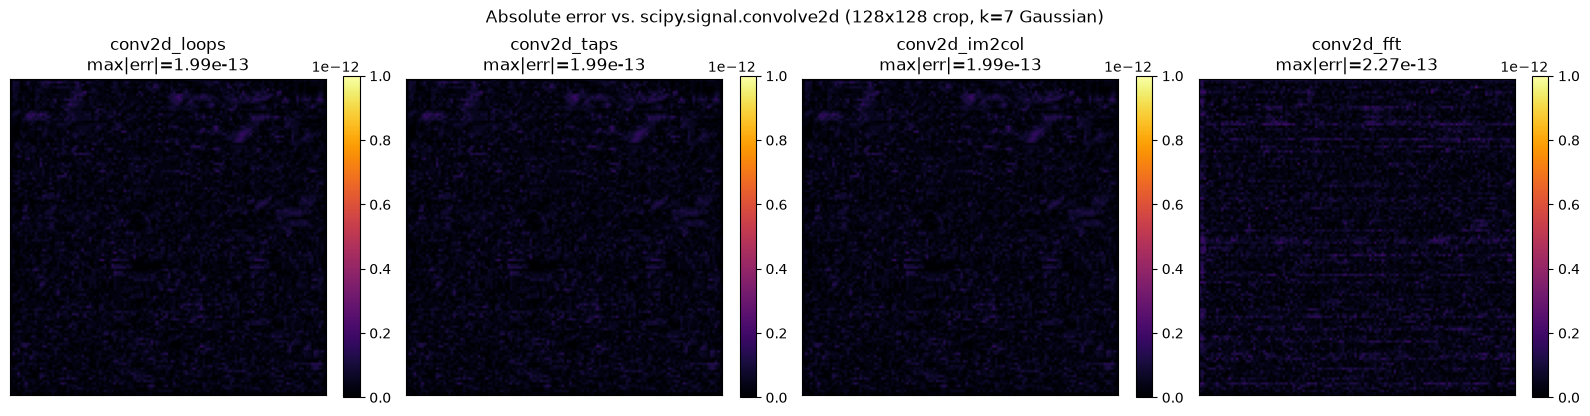

In [7]:
# Per-method |error| heatmaps, shared colour scale
max_err = max(e.max() for e in errors.values())
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, err) in zip(axes, errors.items()):
    im = ax.imshow(err, cmap="inferno", vmin=0, vmax=max(max_err, 1e-12))
    ax.set_title(f"{name}\nmax|err|={err.max():.2e}")
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Absolute error vs. scipy.signal.convolve2d (128x128 crop, k=7 Gaussian)")
fig.tight_layout()
plt.show()